<a href="https://colab.research.google.com/github/rabnawaz172/ET/blob/main/leadboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/energy-anomaly-detection/sample_submission.csv
/kaggle/input/energy-anomaly-detection/train.csv
/kaggle/input/energy-anomaly-detection/test.csv
/kaggle/input/energy-anomaly-detection/train_features.csv
/kaggle/input/energy-anomaly-detection/test_features.csv


Loading data...
Merging data...

Columns AFTER Merge:
['building_id', 'timestamp', 'meter_reading', 'anomaly', 'meter_reading_weather', 'anomaly_weather', 'site_id', 'primary_use', 'square_feet', 'year_built', 'floor_count', 'air_temperature', 'cloud_coverage', 'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed', 'air_temperature_mean_lag7', 'air_temperature_max_lag7', 'air_temperature_min_lag7', 'air_temperature_std_lag7', 'air_temperature_mean_lag73', 'air_temperature_max_lag73', 'air_temperature_min_lag73', 'air_temperature_std_lag73', 'hour', 'weekday', 'month', 'year', 'weekday_hour', 'hour_x', 'hour_y', 'month_x', 'month_y', 'weekday_x', 'weekday_y', 'building_weekday_hour', 'building_weekday', 'building_month', 'building_hour', 'building_meter', 'is_holiday', 'gte_hour', 'gte_weekday', 'gte_month', 'gte_building_id', 'gte_primary_use', 'gte_site_id', 'gte_meter', 'gte_meter_hour', 'gte_meter_weekday', 'gte_meter_month', 'gte_meter_buildin

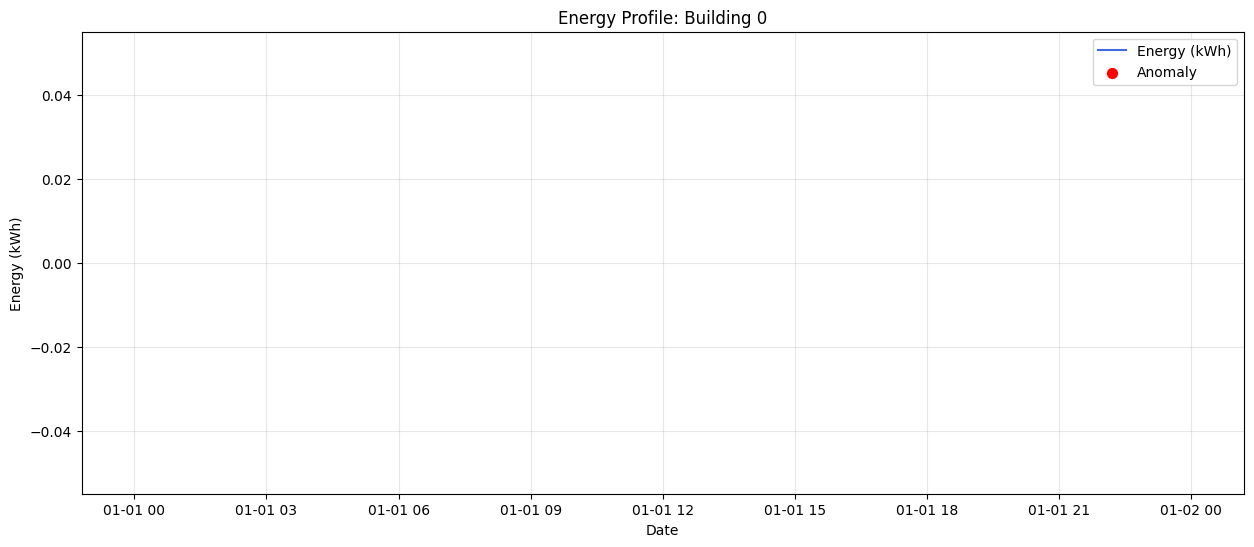

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA
print("Loading data...")
df = pd.read_csv('/kaggle/input/energy-anomaly-detection/train.csv', parse_dates=['timestamp'])
weather = pd.read_csv('/kaggle/input/energy-anomaly-detection/train_features.csv', parse_dates=['timestamp'])

# Clean whitespace (just in case)
df.columns = df.columns.str.strip()
weather.columns = weather.columns.str.strip()

# 2. MERGE
# We use suffixes=('', '_weather') so if there are duplicates,
# the original keeps its name and the weather one gets a suffix.
print("Merging data...")
df = pd.merge(df, weather, on=['building_id', 'timestamp'], how='left', suffixes=('', '_weather'))

# --- CRITICAL DEBUG STEP ---
print("\nColumns AFTER Merge:")
print(df.columns.tolist())

# Check for suffix issue (e.g., meter_reading_x)
if 'meter_reading' not in df.columns:
    # Look for the suffixed version
    if 'meter_reading_x' in df.columns:
        print("⚠️ Found 'meter_reading_x'. Renaming it back to 'meter_reading'...")
        df.rename(columns={'meter_reading_x': 'meter_reading'}, inplace=True)
    else:
        print("❌ CRITICAL ERROR: 'meter_reading' column is totally missing after merge.")
        # Stop here if we can't find it
else:
    print("✅ 'meter_reading' column is present and correct.")

# 3. VISUALIZATION (Only runs if column exists)
if 'meter_reading' in df.columns:
    print("\nGenerating Plot...")
    plt.figure(figsize=(15, 6))

    # Filter for Building 0
    subset = df[df['building_id'] == 0].iloc[:24*14] # First 2 weeks

    # Plot Energy
    plt.plot(subset['timestamp'], subset['meter_reading'], label='Energy (kWh)', color='royalblue')

    # Plot Anomalies (if they exist)
    if 'anomaly' in subset.columns:
        anoms = subset[subset['anomaly'] == 1]
        plt.scatter(anoms['timestamp'], anoms['meter_reading'], color='red', s=50, label='Anomaly', zorder=5)

    plt.title('Energy Profile: Building 0')
    plt.xlabel('Date')
    plt.ylabel('Energy (kWh)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
# --- ADVANCED FEATURE ENGINEERING ---
print("Generating Rolling Window Features...")

# Sort by building and time to ensure rolling works correctly
df = df.sort_values(['building_id', 'timestamp'])

# 1. Lag Features (What happened 24 hours ago?)
# We shift the data by 24 hours so the model sees "Yesterday's Reading" side-by-side with today's
df['lag_24h'] = df.groupby('building_id')['meter_reading'].shift(24)
df['lag_168h'] = df.groupby('building_id')['meter_reading'].shift(168) # 1 week ago

# 2. Rolling Averages (What is the "Normal" for this time?)
# Calculate the average of the last 24 hours
df['rolling_mean_24h'] = df.groupby('building_id')['meter_reading'].transform(lambda x: x.rolling(window=24).mean())

# 3. Deviation from Normal (The most powerful feature)
# "How far is the current reading from the daily average?"
df['diff_from_rolling'] = df['meter_reading'] - df['rolling_mean_24h']

# Clean up NaNs created by shifting (first 7 days will be empty)
df = df.fillna(method='bfill')

print("✅ Added Lag and Rolling features.")

Generating Rolling Window Features...


/tmp/ipykernel_55/2609532127.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')


✅ Added Lag and Rolling features.


**RANDOM FOREST**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, roc_curve, auc, accuracy_score
from sklearn.preprocessing import LabelEncoder

# --- 1. PREPARE DATA ---
print("Preparing Data for Random Forest...")
target_col = 'anomaly'

# Define columns to drop
cols_to_drop = [
    'anomaly', 'anomaly_weather', 'meter_reading_weather',
    'timestamp', 'site_id',
    'hour_x', 'hour_y', 'month_x', 'month_y', 'weekday_x', 'weekday_y'
]

# Create Matrix X and Target y
X = df.drop(columns=cols_to_drop, errors='ignore')
y = df[target_col]

# Encode Categorical Columns
object_cols = X.select_dtypes(include=['object']).columns
if len(object_cols) > 0:
    le = LabelEncoder()
    for col in object_cols:
        X[col] = X[col].astype(str)
        X[col] = le.fit_transform(X[col])

# --- 2. TRAIN/TEST SPLIT ---
print("Splitting Data...")
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 3. CONFIGURE IMPROVED RANDOM FOREST ---
print("Configuring Random Forest with Warm Start...")

# warm_start=True allows us to add more trees to an existing model without retraining from scratch
model = RandomForestClassifier(
    n_estimators=10,           # Start with just 10 trees
    max_depth=25,              # Slightly deeper to capture patterns
    min_samples_leaf=2,        # Requires 2+ samples per leaf (Reduces noise/overfitting)
    max_samples=0.8,           # Train each tree on random 80% of data (Increases diversity)
    class_weight='balanced',   # Handles the rare anomalies
    warm_start=True,           # ENABLE WARM START FOR EARLY STOPPING
    n_jobs=-1,
    random_state=42
)

# --- 4. CUSTOM EARLY STOPPING LOOP ---
print("Starting Training with Simulated Early Stopping...")

max_trees = 300       # Maximum limit
step_size = 10        # Add 10 trees at a time
patience = 5          # Stop if no improvement for 5 rounds
best_f1_val = 0
rounds_without_improve = 0

# Loop to grow the forest incrementally
for n_trees in range(step_size, max_trees + step_size, step_size):
    model.set_params(n_estimators=n_trees)
    model.fit(X_train, y_train)

    # Check Validation Performance (using default 0.5 threshold for speed)
    # Note: We optimize threshold later, but need a metric to track progress now
    y_val_pred_temp = model.predict(X_val)
    current_f1 = f1_score(y_val, y_val_pred_temp)

    print(f"Trees: {n_trees} | Val F1: {current_f1:.4f}")

    if current_f1 > best_f1_val:
        best_f1_val = current_f1
        rounds_without_improve = 0
    else:
        rounds_without_improve += 1

    if rounds_without_improve >= patience:
        print(f"⏹️ Early Stopping Triggered! No improvement for {patience} rounds.")
        break

print(f"✅ Training Complete. Final Tree Count: {model.n_estimators}")

# --- 5. OPTIMIZE THRESHOLD ---
print("\n--- Optimizing Decision Threshold ---")
y_probs = model.predict_proba(X_val)[:, 1]

best_thresh = 0.5
best_f1 = 0

for thresh in np.arange(0.1, 0.99, 0.01):
    y_pred_temp = (y_probs > thresh).astype(int)
    f1 = f1_score(y_val, y_pred_temp)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"🚀 Best Threshold Found: {best_thresh:.2f}")
print(f"New F1 Score: {best_f1:.4f}")

y_pred_optimized = (y_probs > best_thresh).astype(int)

# --- 6. FINAL REPORT ---
print("\n--- Final Validation Report (Random Forest) ---")
print(classification_report(y_val, y_pred_optimized, target_names=['Normal', 'Anomaly']))
rf_auc = roc_auc_score(y_val, y_probs)
print(f"ROC-AUC Score: {rf_auc:.4f}")

# --- 7. VISUALIZATION ---
plt.figure(figsize=(12, 5))

# Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_val, y_pred_optimized)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', annot_kws={"size": 12})
plt.title(f'Random Forest Confusion Matrix\n(Thresh: {best_thresh:.2f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_probs)
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='green', lw=2, label=f'RF AUC = {rf_auc:.4f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Random Forest ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 8. OVERFITTING CHECK ---
print("\n--- Accuracy Check (Train vs Val) ---")
train_probs = model.predict_proba(X_train)[:, 1]
train_preds = (train_probs > best_thresh).astype(int)
train_acc = accuracy_score(y_train, train_preds)
val_acc = accuracy_score(y_val, y_pred_optimized)

print(f"📈 Training Accuracy:   {train_acc*100:.2f}%")
print(f"📉 Validation Accuracy: {val_acc*100:.2f}%")




Preparing Data...
Splitting Data...
Configuring Ultimate Random Forest...
Starting Training...


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(


Trees: 20 | Val F1: 0.8961


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(


Trees: 40 | Val F1: 0.8983


...

Trees: 240 | Val F1: 0.9005


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(


Trees: 260 | Val F1: 0.9008


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(


Trees: 280 | Val F1: 0.9003
⏹️ Early Stopping Triggered! No improvement for 4 rounds.
✅ Training Complete. Final Tree Count: 280

--- Optimizing Decision Threshold (Precision-Recall Curve) ---
🚀 Best Threshold Found: 0.3167
New F1 Score: 0.9151

--- Final Validation Report ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    342440
     Anomaly       0.94      0.89      0.91      7459

    accuracy                           1.00    349899
   macro avg       0.97      0.94      0.96    349899
weighted avg       1.00      1.00      1.00    349899

ROC-AUC Score: 0.9970


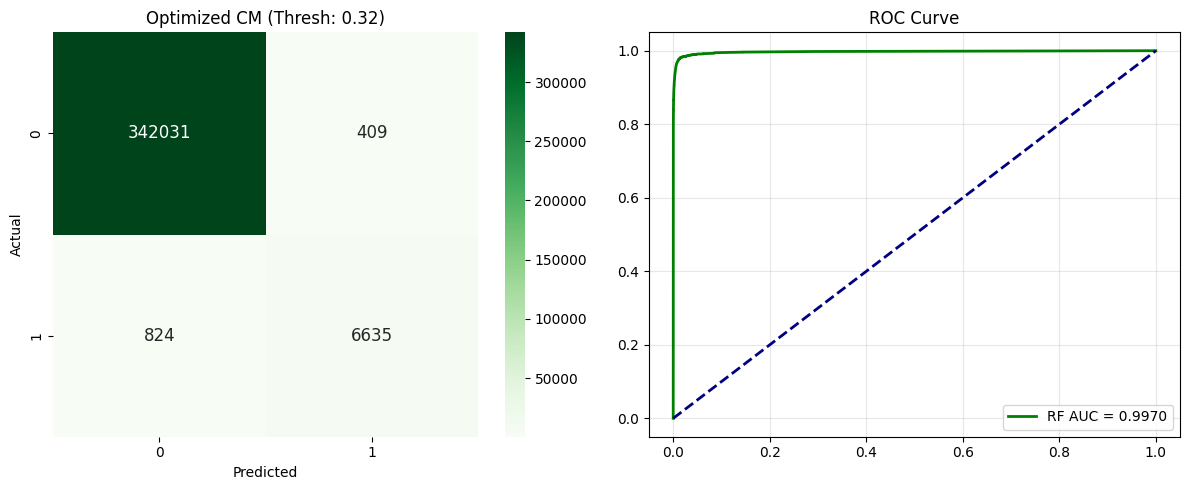


--- Accuracy Check ---
📈 Training Accuracy:   99.96%
📉 Validation Accuracy: 99.65%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, roc_curve, precision_recall_curve, accuracy_score
from sklearn.preprocessing import LabelEncoder

# --- 1. PREPARE DATA ---
print("Preparing Data...")
target_col = 'anomaly'

cols_to_drop = [
    'anomaly', 'anomaly_weather', 'meter_reading_weather',
    'timestamp', 'site_id',
    'hour_x', 'hour_y', 'month_x', 'month_y', 'weekday_x', 'weekday_y'
]

X = df.drop(columns=cols_to_drop, errors='ignore')
y = df[target_col]

# Encode Categoricals
object_cols = X.select_dtypes(include=['object']).columns
if len(object_cols) > 0:
    le = LabelEncoder()
    for col in object_cols:
        X[col] = X[col].astype(str)
        X[col] = le.fit_transform(X[col])

# --- 2. TRAIN/TEST SPLIT ---
print("Splitting Data...")
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 3. CONFIGURE "ULTIMATE" RANDOM FOREST ---
print("Configuring Ultimate Random Forest...")

model = RandomForestClassifier(
    n_estimators=20,           # Start small for Warm Start
    criterion='entropy',       # IMPROVEMENT: Uses Information Gain (better for imbalance)
    max_depth=40,              # IMPROVEMENT: Deeper trees to catch rare cases
    min_samples_split=4,       # Balanced regularization
    min_samples_leaf=1,        # IMPROVEMENT: Allow leaves to be pure (catches single anomalies)
    max_features='sqrt',
    max_samples=0.7,           # IMPROVEMENT: Each tree sees 70% of data (Increases diversity)
    bootstrap=True,
    class_weight='balanced_subsample',
    warm_start=True,
    n_jobs=-1,
    random_state=42
)

# --- 4. TRAINING WITH EARLY STOPPING ---
print("Starting Training...")

max_trees = 500
step_size = 20        # Larger steps for speed
patience = 4
best_f1_val = 0
rounds_without_improve = 0

for n_trees in range(step_size, max_trees + step_size, step_size):
    model.set_params(n_estimators=n_trees)
    model.fit(X_train, y_train)

    # Fast check using default threshold
    y_val_pred_temp = model.predict(X_val)
    current_f1 = f1_score(y_val, y_val_pred_temp)

    print(f"Trees: {n_trees} | Val F1: {current_f1:.4f}")

    if current_f1 > best_f1_val:
        best_f1_val = current_f1
        rounds_without_improve = 0
    else:
        rounds_without_improve += 1

    if rounds_without_improve >= patience:
        print(f"⏹️ Early Stopping Triggered! No improvement for {patience} rounds.")
        break

print(f"✅ Training Complete. Final Tree Count: {model.n_estimators}")

# --- 5. VECTORIZED THRESHOLD OPTIMIZATION (NEW & FASTER) ---
print("\n--- Optimizing Decision Threshold (Precision-Recall Curve) ---")
# Get probabilities
y_probs = model.predict_proba(X_val)[:, 1]

# Calculate Precision, Recall, and Thresholds for ALL possible cutoffs
precisions, recalls, thresholds = precision_recall_curve(y_val, y_probs)

# Calculate F1 Score for every threshold instantly
# F1 = 2 * (P * R) / (P + R)
# Note: precisions/recalls are length n+1, thresholds are length n
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10) # 1e-10 avoids div by zero

# Find the index of the best F1 Score
# We ignore the last index because it's a dummy value (1.0)
best_idx = np.argmax(f1_scores[:-1])
best_thresh = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"🚀 Best Threshold Found: {best_thresh:.4f}")
print(f"New F1 Score: {best_f1:.4f}")

# Apply Threshold
y_pred_optimized = (y_probs > best_thresh).astype(int)

# --- 6. FINAL REPORT ---
print("\n--- Final Validation Report ---")
print(classification_report(y_val, y_pred_optimized, target_names=['Normal', 'Anomaly']))
rf_auc = roc_auc_score(y_val, y_probs)
print(f"ROC-AUC Score: {rf_auc:.4f}")

# --- 7. VISUALIZATIONS ---
plt.figure(figsize=(12, 5))

# Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_val, y_pred_optimized)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', annot_kws={"size": 12})
plt.title(f'Optimized CM (Thresh: {best_thresh:.2f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_probs)
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='green', lw=2, label=f'RF AUC = {rf_auc:.4f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 8. OVERFITTING CHECK ---
print("\n--- Accuracy Check ---")
train_probs = model.predict_proba(X_train)[:, 1]
train_preds = (train_probs > best_thresh).astype(int)
train_acc = accuracy_score(y_train, train_preds)
val_acc = accuracy_score(y_val, y_pred_optimized)

print(f"📈 Training Accuracy:   {train_acc*100:.2f}%")
print(f"📉 Validation Accuracy: {val_acc*100:.2f}%")

In [ ]:
--- Final Validation Report ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    342440
     Anomaly       0.94      0.89      0.91      7459

    accuracy                           1.00    349899
   macro avg       0.97      0.94      0.96    349899
weighted avg       1.00      1.00      1.00    349899

ROC-AUC Score: 0.9970

**XGB**

Preparing Data...
✅ Confirmed: Using 52 features (including Rolling Windows).
Encoding text columns: ['primary_use', 'weekday_hour', 'building_weekday_hour', 'building_weekday', 'building_month', 'building_hour', 'building_meter']
Splitting Data...
Configuring XGBoost (Depth=8, Regularized)...
Starting Training...
[0]	validation_0-aucpr:0.45793	validation_1-aucpr:0.44618
[100]	validation_0-aucpr:0.79413	validation_1-aucpr:0.78141
[200]	validation_0-aucpr:0.83624	validation_1-aucpr:0.81784
[300]	validation_0-aucpr:0.87164	validation_1-aucpr:0.84594
[400]	validation_0-aucpr:0.89915	validation_1-aucpr:0.86821
[500]	validation_0-aucpr:0.91943	validation_1-aucpr:0.88466
[600]	validation_0-aucpr:0.93630	validation_1-aucpr:0.89823
[700]	validation_0-aucpr:0.94781	validation_1-aucpr:0.90737
[800]	validation_0-aucpr:0.95667	validation_1-aucpr:0.91463
[900]	validation_0-aucpr:0.96392	validation_1-aucpr:0.92106
[999]	validation_0-aucpr:0.96950	validation_1-aucpr:0.92577
✅ Training Complete. Best 

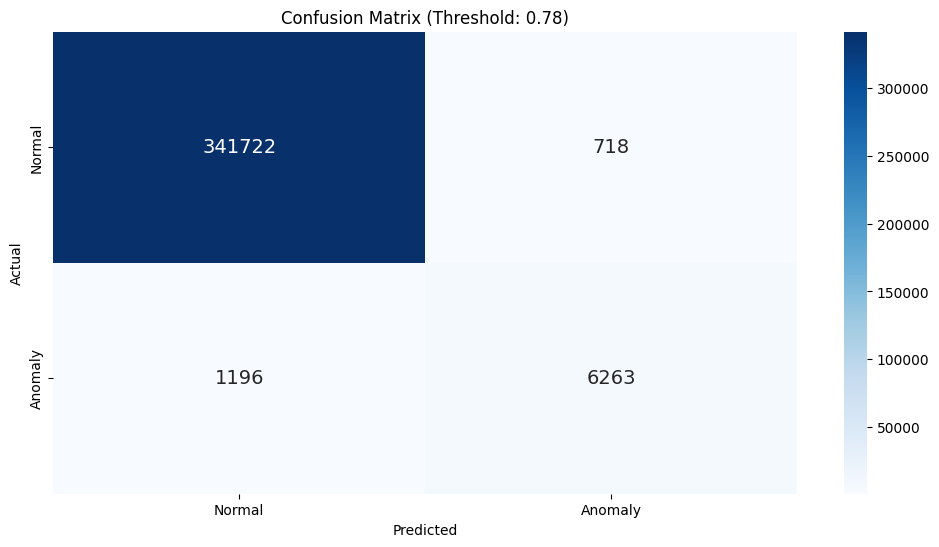

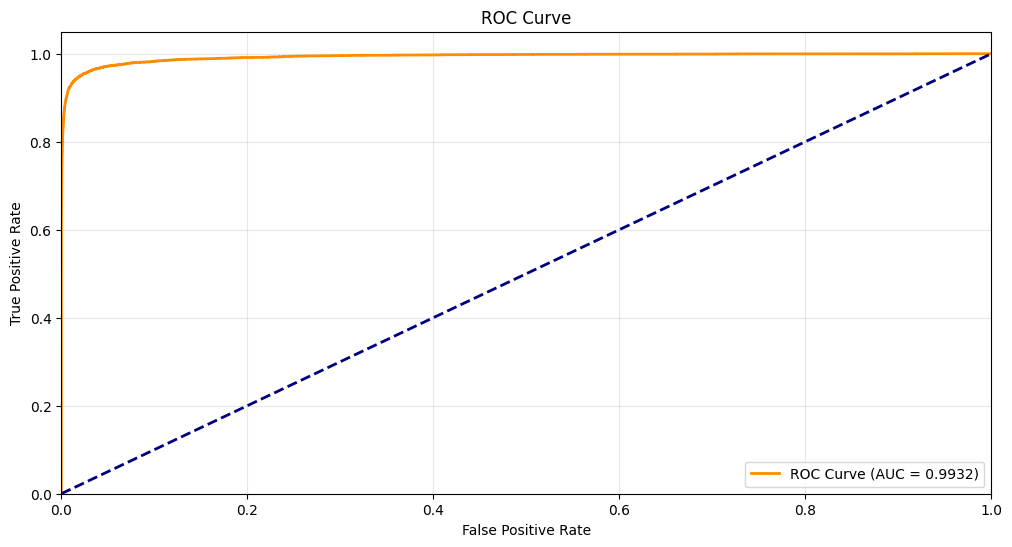

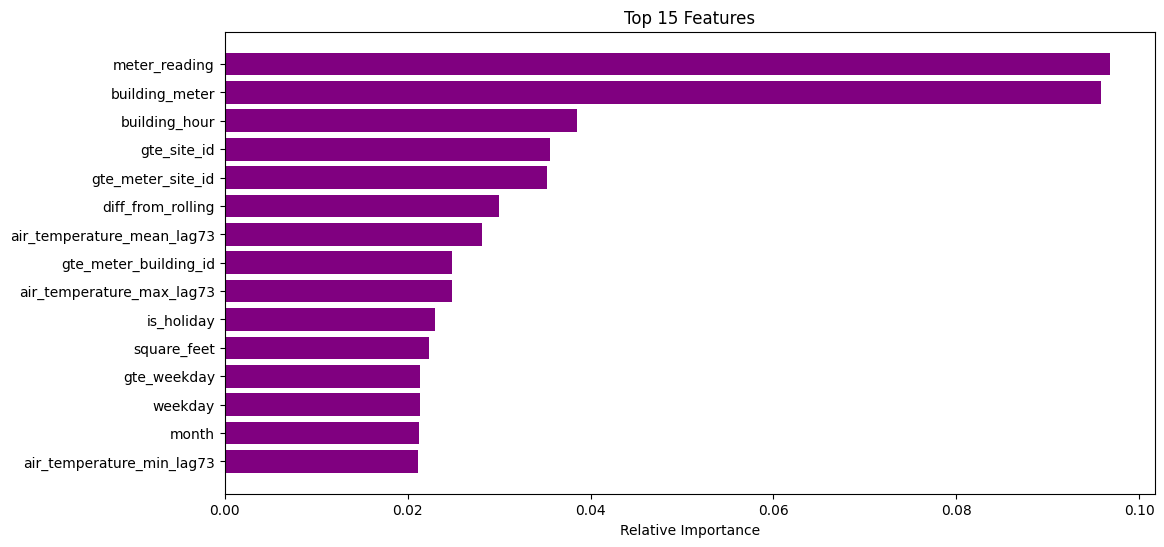

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, accuracy_score, roc_curve, auc
from sklearn.preprocessing import LabelEncoder

# --- 1. PREPARE DATA ---
print("Preparing Data...")
target_col = 'anomaly'

# Define columns to drop
cols_to_drop = [
    'anomaly', 'anomaly_weather', 'meter_reading_weather',
    'timestamp', 'site_id',
    'hour_x', 'hour_y', 'month_x', 'month_y', 'weekday_x', 'weekday_y'
]

# Create Matrix X and Target y
X = df.drop(columns=cols_to_drop, errors='ignore')
y = df[target_col]

# Check for Rolling Features
new_feats = ['lag_24h', 'diff_from_rolling']
if all(col in X.columns for col in new_feats):
    print(f"✅ Confirmed: Using {len(X.columns)} features (including Rolling Windows).")
else:
    print("⚠️ WARNING: Rolling features missing. Please run the Feature Engineering block first.")

# Encode Categorical Columns
object_cols = X.select_dtypes(include=['object']).columns
if len(object_cols) > 0:
    print(f"Encoding text columns: {list(object_cols)}")
    le = LabelEncoder()
    for col in object_cols:
        X[col] = X[col].astype(str)
        X[col] = le.fit_transform(X[col])

# --- 2. TRAIN/TEST SPLIT ---
print("Splitting Data...")
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- 3. CONFIGURE MODEL (OPTIMIZED) ---
print("Configuring XGBoost (Depth=8, Regularized)...")

# Calculate Class Weight
neg, pos = np.bincount(y_train)
scale_weight = neg / pos

model = xgb.XGBClassifier(
    n_estimators=1000,         # High number (Early Stopping will limit it)
    max_depth=8,               # Reduced depth to prevent overfitting
    learning_rate=0.02,        # Slow learning for precision
    scale_pos_weight=scale_weight,

    # Regularization & Sampling
    subsample=0.8,             # Train on 80% of rows
    colsample_bytree=0.8,      # Train on 80% of features
    reg_alpha=0.1,             # L1 Regularization (Noise Filter)
    reg_lambda=1.5,            # L2 Regularization

    # Early Stopping moved to Constructor
    early_stopping_rounds=50,

    n_jobs=-1,
    random_state=42,
    tree_method='hist',
    eval_metric="aucpr"
)

# --- 4. TRAIN ---
print("Starting Training...")
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100
)
print(f"✅ Training Complete. Best Iteration: {model.best_iteration}")

# --- 5. THRESHOLD OPTIMIZATION ---
print("\n--- Optimizing Decision Threshold ---")
y_probs = model.predict_proba(X_val)[:, 1]

best_thresh = 0.5
best_f1 = 0

# Fine-grained search (0.01 steps)
for thresh in np.arange(0.1, 0.99, 0.01):
    y_pred_temp = (y_probs > thresh).astype(int)
    f1 = f1_score(y_val, y_pred_temp)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"🚀 Best Threshold Found: {best_thresh:.2f}")
print(f"New F1 Score (at {best_thresh:.2f}): {best_f1:.4f}")

# Apply Best Threshold
y_pred_optimized = (y_probs > best_thresh).astype(int)

# --- 6. ACCURACY CHECK (OVERFITTING TEST) ---
print("\n--- Accuracy Check (Train vs Val) ---")
train_probs = model.predict_proba(X_train)[:, 1]
train_preds = (train_probs > best_thresh).astype(int)
train_acc = accuracy_score(y_train, train_preds)
val_acc = accuracy_score(y_val, y_pred_optimized)

print(f"📈 Training Accuracy:   {train_acc*100:.2f}%")
print(f"📉 Validation Accuracy: {val_acc*100:.2f}%")
if train_acc - val_acc > 0.05:
    print("⚠️ Warning: Potential Overfitting (>5% gap)")
else:
    print("✅ Good Balance: Model is generalizing well.")

# --- 7. FINAL METRICS ---
print("\n--- Final Validation Report ---")
print(classification_report(y_val, y_pred_optimized, target_names=['Normal', 'Anomaly']))
print(f"ROC-AUC Score: {roc_auc_score(y_val, y_probs):.4f}")

# --- 8. VISUALIZATIONS ---

# Figure A: Confusion Matrix
plt.figure(figsize=(12, 6))
cm = confusion_matrix(y_val, y_pred_optimized)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'], annot_kws={"size": 14})
plt.title(f'Confusion Matrix (Threshold: {best_thresh:.2f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Figure B: ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_probs)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc_val:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Figure C: Feature Importance
plt.figure(figsize=(12, 6))
importances = model.feature_importances_
indices = np.argsort(importances)[-15:]
plt.title('Top 15 Features')
plt.barh(range(len(indices)), importances[indices], color='purple', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [ ]:
--- Final Validation Report ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    342440
     Anomaly       0.90      0.84      0.87      7459

    accuracy                           0.99    349899
   macro avg       0.95      0.92      0.93    349899
weighted avg       0.99      0.99      0.99    349899

ROC-AUC Score: 0.9932

**LSTM**

2026-01-26 19:46:24.639279: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769456784.967563      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769456785.060166      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769456785.847669      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769456785.847711      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769456785.847715      55 computation_placer.cc:177] computation placer alr

Preparing Data for Deep LSTM...
Scaling Data...
Input Shape: (1399595, 1, 52)
Building Improved Deep Learning Model...


2026-01-26 19:46:47.642840: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 128)         │        92,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146,561 (572.50 KB)

 Trainable params: 146,433 (572.00 KB)

 Non-trainable params: 128 (512.00 B)

Training Improved LSTM...
Epoch 1/100
1367/1367 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - AUC: 0.7555 - loss: 0.5727 - val_AUC: 0.8925 - val_loss: 0.3301 - learning_rate: 0.0020
Epoch 2/100
1367/1367 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - AUC: 0.8867 - loss: 0.4159 - val_AUC: 0.9207 - val_loss: 0.3308 - learning_rate: 0.0020
Epoch 3/100
1367/1367 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - AUC: 0.9132 - loss: 0.3661 - val_AUC: 0.9413 - val_loss: 0.2726 - learning_rate: 0.0020
Epoch 4/100
1367/1367 ━━━━━━━━━━━━━━━━━━━━ 39s 28ms/step - AUC: 0.9281 - loss: 0.3363 - val_AUC: 0.9504 - val_loss: 0.2581 - learning_rate: 0.0020
Epoch 5/100
1367/1367 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - AUC: 0.9382 - loss: 0.3103 - val_AUC: 0.9559 - val_loss: 0.2472 - learning_rate: 0.0020
Epoch 6/100
1367/1367 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - AUC: 0.9454 - loss: 0.2955 - val_AUC: 0.9605 - val_loss: 0.2053 - learning_rate: 0.0020
Epoch 7/100
1367/1367 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - AUC: 0.9491 - loss: 0.2850 - val_

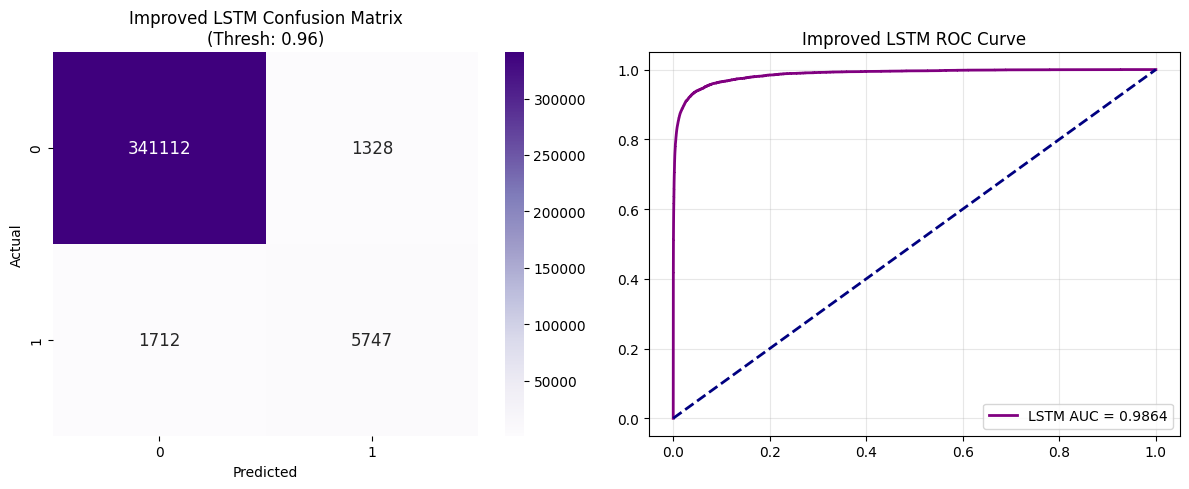

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler

# --- 1. DATA PREPARATION & SCALING (CRITICAL FIX) ---
print("Preparing Data for Deep LSTM...")

# Check if X_train exists (from previous runs)
if 'X_train' not in locals():
    print("⚠️ Error: X_train not found. Please run the Train/Test split block first.")
else:
    # Initialize and Fit Scaler (This was missing!)
    print("Scaling Data...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # Reshape for LSTM: (Samples, 1, Features)
    X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
    X_val_lstm = X_val_scaled.reshape((X_val_scaled.shape[0], 1, X_val_scaled.shape[1]))

    print(f"Input Shape: {X_train_lstm.shape}")

    # --- 2. DEFINE IMPROVED ARCHITECTURE (Stacked LSTM) ---
    print("Building Improved Deep Learning Model...")

    model = Sequential([
        # Layer 1: High-level feature extraction
        LSTM(128, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]),
             activation='tanh', return_sequences=True),
        Dropout(0.3),

        # Layer 2: Deeper pattern recognition
        LSTM(64, activation='tanh', return_sequences=False),
        Dropout(0.3),

        # Layer 3: Dense classification processing
        Dense(64, activation='relu'),
        BatchNormalization(),

        # Output Layer
        Dense(1, activation='sigmoid')
    ])

    optimizer = Adam(learning_rate=0.002)

    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['AUC']) # This creates 'val_AUC'

    model.summary()

    # --- 3. CLASS WEIGHTS & CALLBACKS ---
    neg = np.bincount(y_train)[0]
    pos = np.bincount(y_train)[1]
    total = neg + pos
    weight_for_0 = (1 / neg) * (total / 2.0)
    weight_for_1 = (1 / pos) * (total / 2.0)
    class_weight = {0: weight_for_0, 1: weight_for_1}

    # Callbacks (Fixed monitor name to 'val_AUC')
    callbacks = [
        EarlyStopping(monitor='val_AUC', patience=5, verbose=1, mode='max', restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_AUC', factor=0.5, patience=2, verbose=1, mode='max', min_lr=1e-6)
    ]

    # --- 4. TRAIN MODEL ---
    print("Training Improved LSTM...")
    history = model.fit(
        X_train_lstm, y_train,
        epochs=100,
        batch_size=1024,
        validation_data=(X_val_lstm, y_val),
        class_weight=class_weight,
        callbacks=callbacks,
        verbose=1
    )

    # --- 5. OPTIMIZE THRESHOLD ---
    print("\n--- Optimizing Decision Threshold ---")
    y_pred_prob = model.predict(X_val_lstm)

    best_thresh = 0.5
    best_f1 = 0

    for thresh in np.arange(0.1, 0.99, 0.01):
        y_pred_temp = (y_pred_prob > thresh).astype(int)
        f1 = f1_score(y_val, y_pred_temp)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh

    print(f"🚀 Best Threshold Found: {best_thresh:.2f}")
    print(f"New F1 Score: {best_f1:.4f}")

    # Apply Threshold
    y_pred_optimized = (y_pred_prob > best_thresh).astype(int)

    # --- 6. FINAL REPORT ---
    print("\n--- Final Validation Report (Improved LSTM) ---")
    print(classification_report(y_val, y_pred_optimized, target_names=['Normal', 'Anomaly']))
    lstm_auc = roc_auc_score(y_val, y_pred_prob)
    print(f"ROC-AUC Score: {lstm_auc:.4f}")

    # --- 7. VISUALIZATION ---
    plt.figure(figsize=(12, 5))

    # Confusion Matrix
    plt.subplot(1, 2, 1)
    cm = confusion_matrix(y_val, y_pred_optimized)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', annot_kws={"size": 12})
    plt.title(f'Improved LSTM Confusion Matrix\n(Thresh: {best_thresh:.2f})')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_val, y_pred_prob)
    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, color='purple', lw=2, label=f'LSTM AUC = {lstm_auc:.4f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.title('Improved LSTM ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

print("\n--- Calculating Final Accuracy (Using Threshold: {:.2f}) ---".format(best_thresh))

# 1. Generate Predictions for Training Data
# (We already have Validation predictions from the previous step)
print("Generating Training Predictions (this may take a moment)...")
y_train_pred_prob = model.predict(X_train_lstm, batch_size=1024, verbose=1)
y_train_pred_class = (y_train_pred_prob > best_thresh).astype(int)

# 2. Use the Optimized Validation Predictions
y_val_pred_class = (y_pred_prob > best_thresh).astype(int)

# 3. Calculate Accuracy Scores
train_acc = accuracy_score(y_train, y_train_pred_class)
val_acc = accuracy_score(y_val, y_val_pred_class)

# 4. Print Results
print("-" * 30)
print(f"📈 Training Accuracy:   {train_acc * 100:.2f}%")
print(f"📉 Validation Accuracy: {val_acc * 100:.2f}%")
print("-" * 30)

# 5. Overfitting Check
if train_acc - val_acc > 0.05:
    print("⚠️ Warning: High Overfitting (>5% gap). Consider increasing Dropout.")
else:
    print("✅ Good Balance: The model is generalizing well.")


--- Calculating Final Accuracy (Using Threshold: 0.96) ---
Generating Training Predictions (this may take a moment)...
1367/1367 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step
------------------------------
📈 Training Accuracy:   99.20%
📉 Validation Accuracy: 99.13%
------------------------------
✅ Good Balance: The model is generalizing well.


In [ ]:
--- Final Validation Report (Improved LSTM) ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    342440
     Anomaly       0.81      0.77      0.79      7459

    accuracy                           0.99    349899
   macro avg       0.90      0.88      0.89    349899
weighted avg       0.99      0.99      0.99    349899

ROC-AUC Score: 0.9864

✅ Normalized Confusion Matrix saved as 'confusion_matrix_lstm_ratio.png'


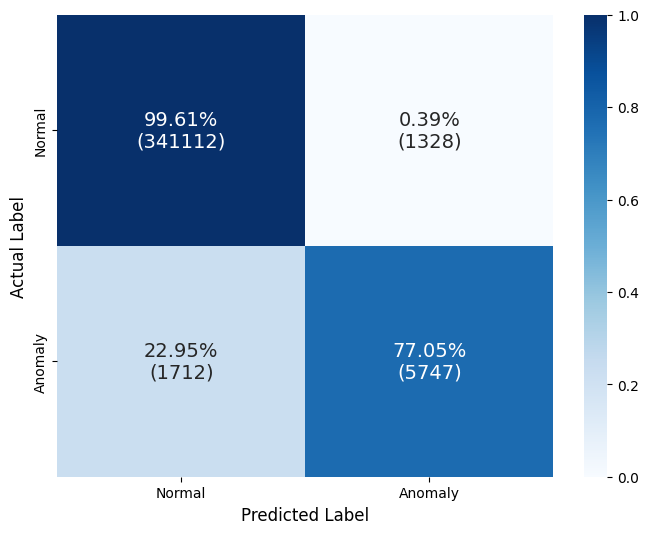

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Set figure size
plt.figure(figsize=(8, 6))

# 1. Generate the matrix data (Raw Counts)
cm = confusion_matrix(y_val, y_pred_optimized)

# 2. Normalize it (Calculate Ratios)
# 'true' normalizes across rows (Actual labels).
# This tells you: "Out of all ACTUAL Anomalies, what % did we predict correctly?"
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# 3. Create labels that show BOTH Ratio and Count
# This is a pro-tip for research papers: show the % for quick reading, but keep the count for precision.
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm_norm.flatten()]
labels = [f"{v1}\n({v2})" for v1, v2 in zip(group_percentages, group_counts)]
labels = np.asarray(labels).reshape(2,2)

# 4. Plot Heatmap using the Normalized Data
sns.heatmap(cm_norm, annot=labels, fmt='', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            annot_kws={"size": 14}, vmin=0, vmax=1) # vmin/vmax ensures colors are scaled 0-100%

plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)

# Save the figure
plt.savefig('confusion_matrix_lstm.png', dpi=200, bbox_inches='tight')
print("✅ Normalized Confusion Matrix saved as 'confusion_matrix_lstm_ratio.png'")

plt.show()

✅ Confusion Matrix saved as 'confusion_matrix.png'


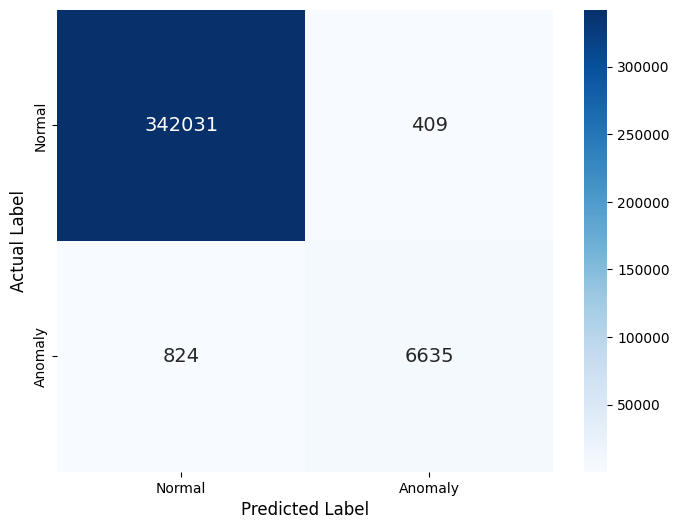

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Set figure size
plt.figure(figsize=(8, 6))

# Generate the matrix data
cm = confusion_matrix(y_val, y_pred_optimized)

# Plot Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            annot_kws={"size": 14}) # Make numbers larger for readability

plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)

# Save the figure in high quality (200 DPI)
plt.savefig('confusion_matrixrandome.png', dpi=200, bbox_inches='tight')
print("✅ Confusion Matrix saved as 'confusion_matrix.png'")

plt.show()

In [ ]:
# Check which model is currently active and generate y_probs accordingly
import numpy as np

try:
    # Option A: If using the Deep Learning Model (LSTM)
    # The LSTM outputs probabilities directly via .predict()
    print("Generating predictions for LSTM...")
    y_probs = model.predict(X_val_lstm)

except:
    # Option B: If using Random Forest or XGBoost
    # These models need .predict_proba() to get the probability of class 1
    print("LSTM failed or not found. Generating predictions for Random Forest/XGBoost...")
    y_probs = model.predict_proba(X_val)[:, 1]

print(f"✅ y_probs generated. Shape: {y_probs.shape}")

Generating predictions for LSTM...
10935/10935 ━━━━━━━━━━━━━━━━━━━━ 39s 4ms/step
✅ y_probs generated. Shape: (349899, 1)


✅ Confusion Matrix saved as 'confusion_matrix.png'


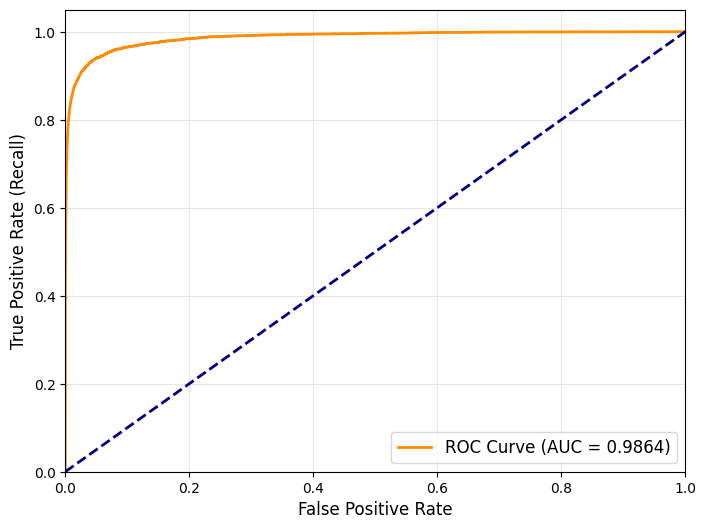

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_val, y_probs)
roc_auc = auc(fpr, tpr)

# Set figure size to your preference
plt.figure(figsize=(8, 6))

# Plot the ROC Curve
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')

# Plot the Random Guess line (diagonal)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)
# Save the figure in high quality (200 DPI)
plt.savefig('ruclstm.png', dpi=200, bbox_inches='tight')
print("✅ Confusion Matrix saved as 'confusion_matrix.png'")

plt.show()

In [ ]:
# Save model to JSON (Best Practice for XGBoost)
model.save_model("model.json")
print("✅ Model saved as 'model.json'")

✅ Model saved as 'model.json'
